In [ ]:
pip install pandas geopandas numpy matplotlib seaborn

<center><h1>Analisis de Datos IDEAM</h1>

### El dataset es sobre los datos recogidos por estaciones de meteorología del IDEAM y terceros.

</center>

#### Qué representa cada registro?

Cada registro muestra los datos tomados por un sensor dado de cada estación meteorologíca; cada sensor puede tomar datos como precipitación, temperatura, vel. viento, etc, tanto del IDEAM como de terceros que le reportan al IDEAM.

Enlace del dataset: https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Datos-de-Estaciones-de-IDEAM-y-de-Terceros/57sv-p2fu/about_data.
_Se actualiza diariamente_


#### Importacion de librerías

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<center>

### Inspección inicial
</center>

##### Cargue y Lectura del archivo csv:

In [14]:
df = pd.read_csv("Datos_de_Estaciones_de_IDEAM_y_de_Terceros_20250902.csv")

##### Vista de encabezados:
La instrucción df.head() muestra las primeras cinco filas del dataset, lo cual permite verificar que los datos se han cargado correctamente y observar ejemplos reales de cada columna.

In [15]:
# Ver primeras filas
df.head()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida,Entidad
0,17015010,111,2025 Sep 01 04:02:00 AM,2.1,AEROPUERTO SESQUICENTENARIO,ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA...,SAN ANDRÉS,ISLAS CARIBE,12.587849,-81.701117,GPRS - VELOCIDAD DEL VIENTO,m/s,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...
1,21205791,257,2025 Sep 02 12:32:00 AM,0,EL DORADO CATAM,BOGOTÁ,BOGOTÁ D.C,ALTO MAGDALENA,4.705583,-74.150667,GPRS - PRECIPITACIÓN,mm,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...
2,23085270,71,2025 Sep 02 07:36:00 AM,15.6,AEROPUERTO J.M. CORDOVA,ANTIOQUIA,RIONEGRO,MEDIO MAGDALENA,6.168611,-75.426111,GPRS - TEMPERATURA DEL AIRE A 2 m,°C,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...
3,24035340,111,2025 Sep 01 04:00:00 AM,0.8,AEROPUERTO A LLERAS C,BOYACÁ,SOGAMOSO,SOGAMOSO,5.676944,-72.967917,GPRS - VELOCIDAD DEL VIENTO,m/s,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...
4,2120000120,240,2025 Sep 01 08:12:00 PM,0,COL. GUSTAVO MORALES,BOGOTÁ,BOGOTÁ D.C,ALTO MAGDALENA,4.716619,-74.064401,PRECIPITACIÓN,mm,INSTITUTO DISTRITAL DE GESTIÓN DE RIESGOS Y CA...


Columnas clave:
- Aparecen identificadores (CodigoEstacion, CodigoSensor)
- La fecha de la observación (FechaObservacion)
- El valor medido (ValorObservado)
- Metadatos como ubicación (Departamento, Municipio, Latitud, Longitud)
- Descripción (DescripcionSensor, UnidadMedida, Entidad).

Por ejemplo, en la primera fila, el sensor de velocidad del viento en el Aeropuerto Sesquicentenario reportó 2.1 m/s el 1 de septiembre de 2025 a las 04:02 AM.

Esto confirma que los datos representan mediciones meteorológicas e hidrológicas en diferentes estaciones del país, con sus atributos geográficos y técnicos.

##### Ver columnas y los tipos:

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554828 entries, 0 to 554827
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CodigoEstacion     554828 non-null  int64  
 1   CodigoSensor       554828 non-null  int64  
 2   FechaObservacion   554828 non-null  object 
 3   ValorObservado     554828 non-null  object 
 4   NombreEstacion     554828 non-null  object 
 5   Departamento       554828 non-null  object 
 6   Municipio          554828 non-null  object 
 7   ZonaHidrografica   554828 non-null  object 
 8   Latitud            554828 non-null  float64
 9   Longitud           554828 non-null  float64
 10  DescripcionSensor  554828 non-null  object 
 11  UnidadMedida       554828 non-null  object 
 12  Entidad            554828 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 55.0+ MB


La instrucción df.info() devuelve información estructural del DataFrame:

- Número de registros: 554,828 filas → es un dataset grande, lo que implica que se pueden hacer análisis estadísticos sólidos.

- Columnas totales: 13.

Tipos de datos:

- int64: códigos de estación y sensor.

- float64: latitud y longitud (correcto para análisis geográfico).

- object: la mayoría de columnas (incluyendo fecha y valores observados).

##### Estadísticas básicas:

In [17]:
df.describe(include="all")

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida,Entidad
count,5.548280e+05,554828.000000,554828,554828,554828,554828,554828,554828,554828.000000,554828.000000,554828,554828,554828
unique,NaN,NaN,11538,10670,564,33,362,31,NaN,NaN,17,9,9
top,NaN,NaN,2025 Sep 01 08:00:00 PM,0,AEROPUERTO EL EMBRUJO,BOGOTÁ,BOGOTÁ D.C,ALTO MAGDALENA,NaN,NaN,PRECIPITACIÓN,mm,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...
freq,NaN,NaN,2971,206847,42718,87683,86268,139595,NaN,NaN,183570,213044,474066
mean,5.653633e+08,163.119147,NaN,NaN,NaN,NaN,NaN,NaN,6.306802,-75.091644,NaN,NaN,NaN
std,1.058415e+09,81.982168,NaN,NaN,NaN,NaN,NaN,NaN,3.501997,2.448299,NaN,NaN,NaN
min,1.102703e+07,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,-4.199509,-81.703389,NaN,NaN,NaN
25%,2.120219e+07,103.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.517247,-75.760000,NaN,NaN,NaN
50%,2.607515e+07,111.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.301109,-74.520080,NaN,NaN,NaN
75%,5.205008e+07,240.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.227690,-73.790000,NaN,NaN,NaN


La instrucción df.describe muestra que datos hay en cada columna, de las cuales se notan dos:

1. Columnas numéricas

    A. CodigoEstacion / CodigoSensor:

    * mean (promedio) y std (desviación estándar) no son muy útiles aquí, porque son identificadores, no magnitudes físicas.
    * El rango (min → max) confirma que hay estaciones desde IDs pequeños hasta IDs muy grandes.

    B. Latitud / Longitud:

    * Latitud: entre -4.19° y 13.36° → corresponde a territorio colombiano (desde el sur en el Amazonas hasta San Andrés en el norte)
    * Longitud: entre -81.70° y -67.85° → coincide también con Colombia, desde el Caribe hasta la zona oriental.

            Esto confirma que la cobertura de la red de estaciones es nacional.

2. Columnas categóricas

    A. FechaObservacion:

    * Tiene 11,538 fechas únicas en el dataset.

    * La más frecuente: “2025 Sep 01 08:00:00 PM” (con 2,971 registros). 
    
            Esto muestra que hay momentos en los que muchas estaciones reportan al mismo tiempo (sincronización en los envíos).

    B. ValorObservado:

    * Tiene 10,670 valores distintos.
    * El valor más frecuente es 0, con 206,847 apariciones.
    
            Esto indica que muchos sensores (sobre todo de precipitación) reportan “0” cuando no hay lluvia.

    C. NombreEstacion:

    * 564 estaciones distintas.

            La más frecuente: Aeropuerto El Embrujo (42,718 registros).

    D. Departamento:

    * 33 departamentos representados.

            El más frecuente: Bogotá (87,683 registros).

    E. Municipio:

    * 362 municipios distintos.

            El más frecuente: Bogotá D.C (86,268 registros).

    F. ZonaHidrografica:

    * 31 zonas distintas.

            La más frecuente: Alto Magdalena (139,595 registros).

    G. DescripcionSensor:

    * 17 tipos de sensores distintos.

            El más frecuente: Precipitación (183,570 registros).

    H. UnidadMedida:

    * 9 tipos de unidades (m/s, mm, °C, %, hPa, etc.).

            La más común: mm (213,044 registros).

    I. Entidad:

    * 9 entidades diferentes.

            La más frecuente: IDEAM (Instituto de Hidrología, Meteorología y Estudios Ambientales) con 474,066 registros.

## Exploracion de Datos

##### Cantidad de estaciones y sensores distintos:

In [18]:
print("Estaciones únicas:", df["NombreEstacion"].nunique())
print("Sensores únicos:", df["DescripcionSensor"].nunique())

Estaciones únicas: 564
Sensores únicos: 17


##### Valores máximos, mínimos y promedio por tipo de sensor:

In [19]:
#Imprimir la cantidad de sensores
df["ValorObservado"] = (
    df["ValorObservado"]
    .astype(str)                # por si vienen como object
    .str.replace(",", "")       # eliminar comas
    .astype(float)              # convertir a número
)

resultado = df.groupby("DescripcionSensor")["ValorObservado"].agg(["mean", "min", "max"])
print(resultado)

                                         mean     min        max
DescripcionSensor                                               
DIRECCIÓN DEL VIENTO               170.743532    0.00   360.0000
GPRS - HUMEDAD DEL AIRE A 2 m       82.457943    0.00   100.0000
GPRS - NIVEL                         0.804084    0.42     5.8300
GPRS - PRECIPITACIÓN                 0.007049    0.00     3.6000
GPRS - PRESIÓN ATMOSFÉRICA         942.151697  715.90  1015.1000
GPRS - TEMPERATURA DEL AIRE A 2 m   24.642373    0.10    38.0000
GPRS - VELOCIDAD DEL VIENTO          2.698257    0.00    14.4000
HUMEDAD DEL SUELO A 1 m Ó MAS       79.949168    0.00   100.0000
NIVEL INSTANTANEO                   10.794987    0.00   439.0996
NIVEL MÁXIMO                         2.961406    0.00   105.4100
NIVEL MÍNIMO                         2.835812    0.00   105.4100
PRECIPITACIÓN                        0.077249    0.00    30.0000
PRESIÓN ATMOSFÉRICA                867.955897  499.40  1016.0000
TEMPERATURA DEL AIRE A 2 

##### Distribución por departamentos o municipios:

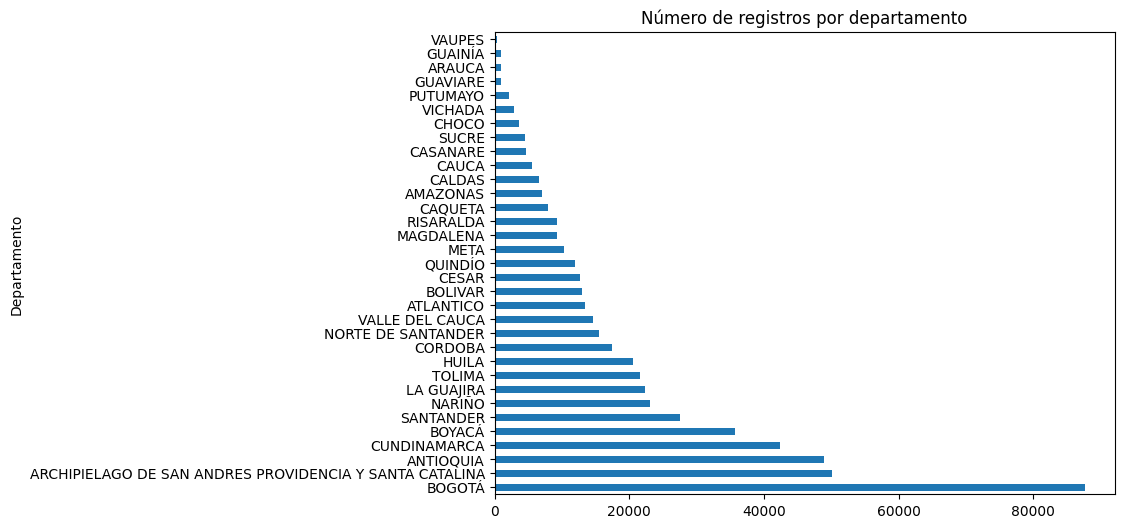

In [20]:
df["Departamento"].value_counts().plot(kind="barh", figsize=(8,6))
plt.title("Número de registros por departamento")
plt.show()

## Visualizaciones útiles

##### Histogramas de valores (ejemplo humedad, viento, presión):

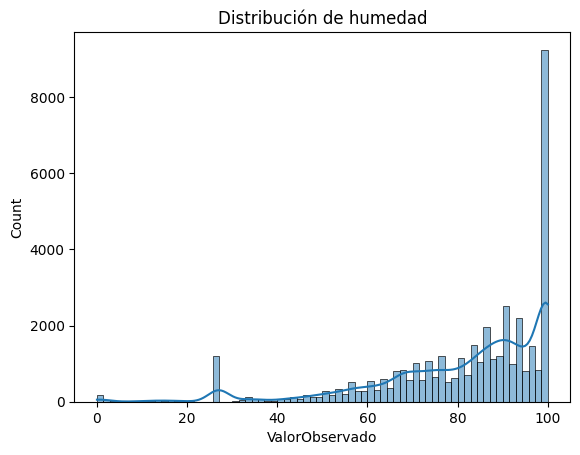

In [21]:
sns.histplot(df[df["DescripcionSensor"].str.contains("HUMEDAD")]["ValorObservado"], kde=True)
plt.title("Distribución de humedad")
plt.show()

##### Ubicación geográfica de estaciones (Lat/Lon):

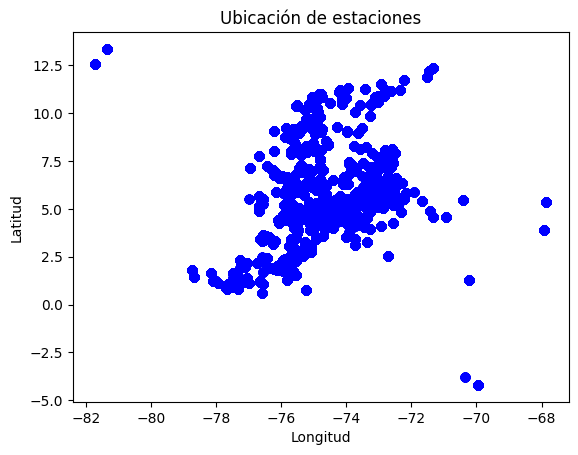

In [22]:
plt.scatter(df["Longitud"], df["Latitud"], c="blue", alpha=0.6)
plt.title("Ubicación de estaciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

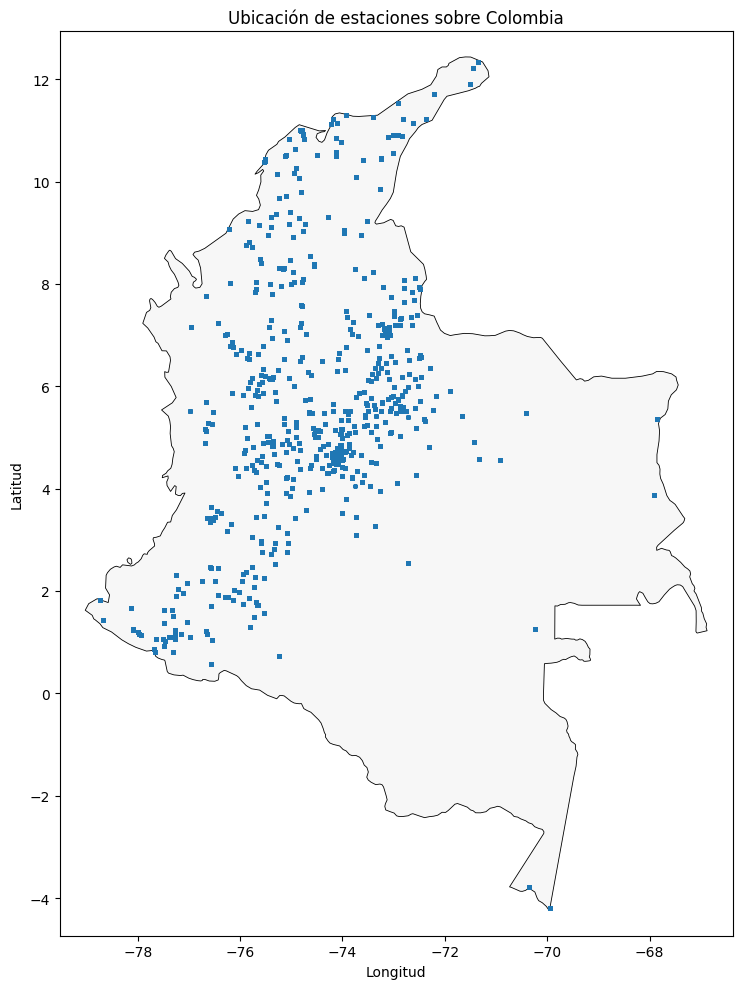

In [23]:
# 1) Cargar países desde Natural Earth (elige 110m/50m/10m según nivel de detalle)
def load_countries(res="50m"):
    urls = {
        "110m": "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
        "50m":  "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip",
        "10m":  "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip",
    }
    return gpd.read_file(urls[res])

world = load_countries("50m")

# 2) Identificar la columna de nombre (puede ser ADMIN / NAME / name según la versión)
name_col = next(c for c in ["ADMIN", "NAME", "name", "NAME_LONG"] if c in world.columns)

# 3) Filtrar Colombia
col = world[world[name_col].str.contains("Colombia", case=False, na=False)].copy()

# 4) (Opcional) asegurar CRS geográfico
if col.crs is None:
    col = col.set_crs("EPSG:4326")

# 5) Dibujar base de Colombia
ax = col.plot(edgecolor="black", facecolor="#f7f7f7", linewidth=0.6, figsize=(8,10))

# 6) Tus puntos (df debe tener columnas 'Longitud' y 'Latitud' ya en grados)
ax.scatter(df["Longitud"], df["Latitud"], s=6, alpha=0.7)

# 7) Aspecto y encuadre
minx, miny, maxx, maxy = col.total_bounds
ax.set_xlim(minx - 0.5, maxx + 0.5)
ax.set_ylim(miny - 0.5, maxy + 0.5)
ax.set_aspect("equal", adjustable="box")

ax.set_title("Ubicación de estaciones sobre Colombia")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")

plt.tight_layout()
plt.show()

##### Mapa de Calor

Mapa de calor erroneo

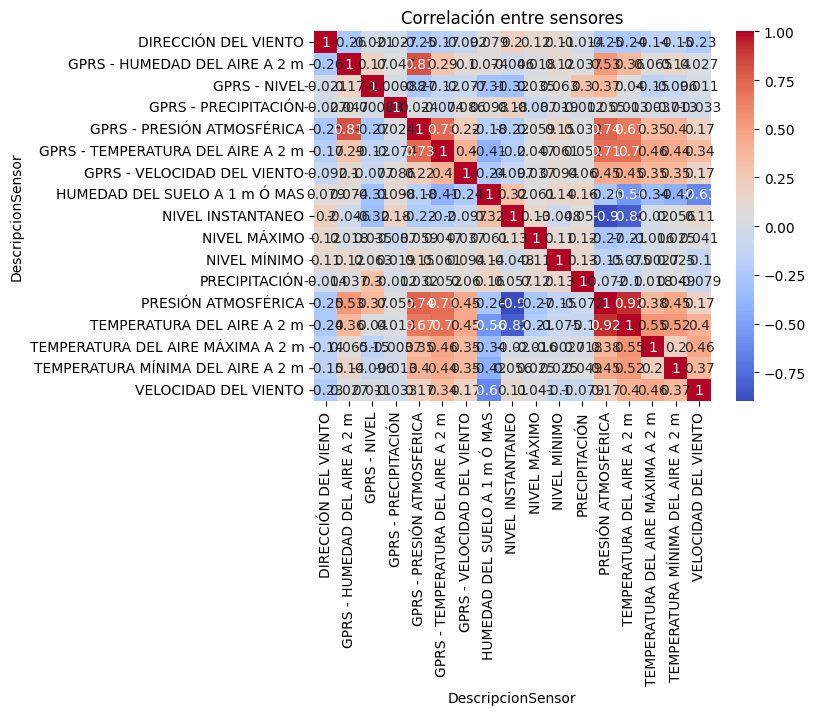

In [24]:
pivot = df.pivot_table(index="FechaObservacion", 
                       columns="DescripcionSensor", 
                       values="ValorObservado", aggfunc="mean")
sns.heatmap(pivot.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre sensores")
plt.show()

Mapa de Calor corregido por el practicante

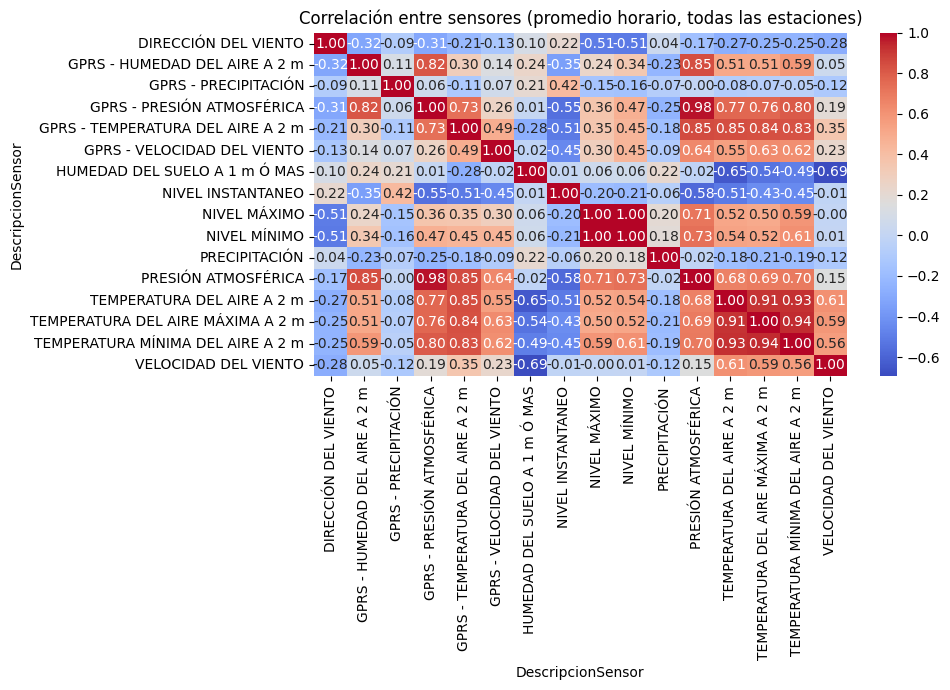

In [25]:
# 1) Limpieza de tipos
# - Fecha a datetime
df["FechaObservacion"] = pd.to_datetime(df["FechaObservacion"], errors="coerce")

# - ValorObservado a float (elimina comas de miles y espacios)
vo = (
    df["ValorObservado"]
    .astype(str)
    .str.replace(",", "", regex=False)   # "1,008.6" -> "1008.6"
    .str.strip()
)
# Convierte a numérico; lo que no se pueda, queda NaN
df["ValorObservado"] = pd.to_numeric(vo, errors="coerce")

# 2) Filtrado básico: fuera filas sin fecha o sin valor numérico
df_clean = df.dropna(subset=["FechaObservacion", "ValorObservado"]).copy()

# 3) (Opcional pero recomendado) Normaliza etiquetas de sensor para evitar pequeñas variaciones
#    Si no lo necesitas, puedes comentar esta línea.
df_clean["DescripcionSensor"] = df_clean["DescripcionSensor"].str.strip()

# 4) Alineación temporal:
#    Promediamos por hora para cada tipo de sensor (agrega todas las estaciones).
g = (
    df_clean
    .set_index("FechaObservacion")
    .groupby("DescripcionSensor")["ValorObservado"]
    .resample("1H")            # cambia a '30min' o '3H' si quieres otra resolución
    .mean()
    .unstack(0)                # columnas = DescripcionSensor
    .sort_index()
)

# 5) (Opcional) descarta sensores con muy pocos datos tras el resample
min_obs = 50
g = g.loc[:, g.count() >= min_obs]

# 6) Matriz de correlación (exigiendo traslape mínimo para estabilidad)
corr = g.corr(min_periods=30)

# 7) Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre sensores (promedio horario, todas las estaciones)")
plt.tight_layout()
plt.show()


In [26]:
# 1) Quedarnos solo con HUMEDAD
hum = df[df["DescripcionSensor"].str.contains("HUMEDAD", case=False)].copy()

# 2) Asegurar numérico (quita comas de miles y espacios)
hum["ValorObservado"] = (
    hum["ValorObservado"].astype(str).str.replace(",", "", regex=False).str.strip()
)
hum["ValorObservado"] = pd.to_numeric(hum["ValorObservado"], errors="coerce")

# 3) Filtrar al rango físico 0–100 %
hum = hum[hum["ValorObservado"].between(0, 100)]

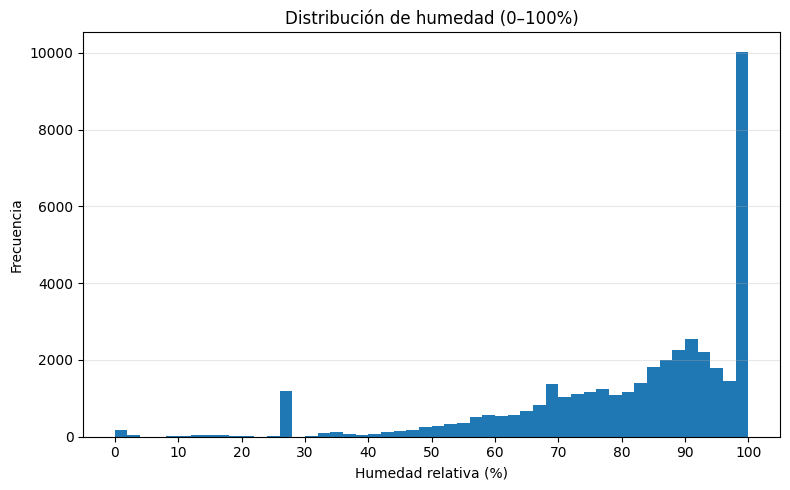

In [27]:
bins = np.arange(0, 101, 2)  # bin de 2%

plt.figure(figsize=(8,5))
plt.hist(hum["ValorObservado"], bins=bins)
plt.title("Distribución de humedad (0–100%)")
plt.xlabel("Humedad relativa (%)")
plt.ylabel("Frecuencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

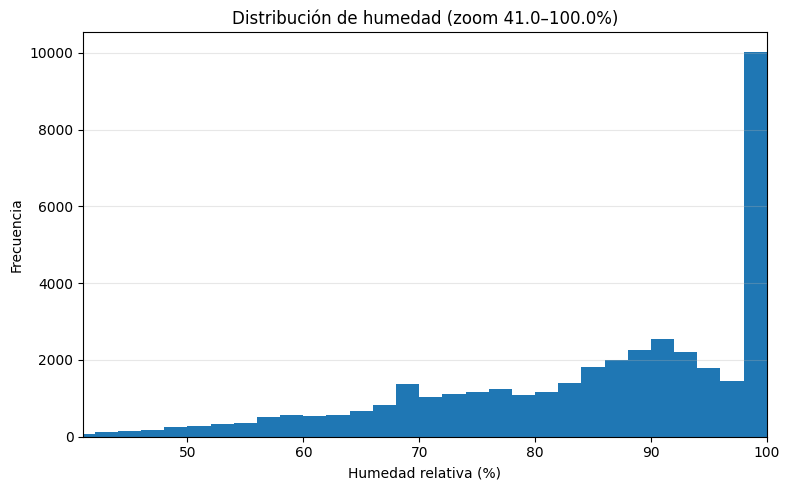

In [28]:
p5, p95 = hum["ValorObservado"].quantile([0.05, 0.95])
plt.figure(figsize=(8,5))
plt.hist(hum["ValorObservado"], bins=50)
plt.xlim(p5, p95)  # enfoca el 90% central
plt.title(f"Distribución de humedad (zoom {p5:.1f}–{p95:.1f}%)")
plt.xlabel("Humedad relativa (%)")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

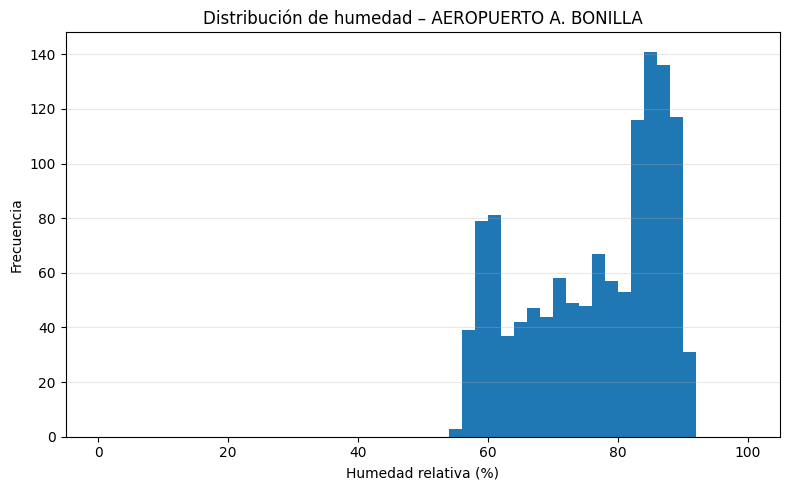

In [29]:
est = "AEROPUERTO A. BONILLA"
hum_est = hum[hum["NombreEstacion"] == est]
plt.figure(figsize=(8,5))
plt.hist(hum_est["ValorObservado"], bins=bins)
plt.title(f"Distribución de humedad – {est}")
plt.xlabel("Humedad relativa (%)"); plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout(); plt.show()